# Notebook 10: Polynomial features and PCA

Degree-2 polynomial expansion generates every squared term and pairwise product of the continuous features, which quickly produces hundreds of correlated columns. PCA rotates that expanded set into orthogonal components ordered by variance, and cross-validation over component counts finds how many are worth keeping.

Two caveats worth teaching: binary indicator columns are excluded from the expansion because their squares equal themselves and products within a one-hot group are always zero; and PCA is fit on the full dataset before cross-validation, which is acceptable here because PCA never sees the target, but a strict production pipeline would fit it inside each fold.

## 1. Notebook set-up

In [1]:
import sys
from pathlib import Path

import pandas as pd
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sys.path.insert(0, str(Path.cwd().resolve().parent / 'src'))
import featurely as fl

from config import (
    DATA_DIR,
    PIPELINE_COLORS,
    PIPELINE_RESULTS_PATH,
    POLY_DEGREE,
 )

## 2. Data loading

In [2]:
in_path = DATA_DIR / '09-smoothing.csv'

if not in_path.exists():
    raise FileNotFoundError(
        (f'Missing required input file: {in_path}. Run 09-smoothing.ipynb ' +
         'first to generate data/09-smoothing.csv.')
    )

housing_df = pd.read_csv(in_path)
print(f'Loaded: {in_path}')

Loaded: /workspaces/featurely/data/fsa-feature-engineering-challenge/09-smoothing.csv


## 3. Polynomial feature expansion

Continuous columns are expanded; binary indicators pass through unchanged and are concatenated back after the expansion. The expanded frame is saved as its own artifact so later work can reuse it without recomputing.

In [3]:
feature_cols = [c for c in housing_df.columns if c != 'MedHouseVal']

# Squares of binary columns equal themselves and products within a one-hot
# group are always zero, so expanding them only adds redundant columns.
binary_cols = [c for c in feature_cols if housing_df[c].nunique() <= 2]
continuous_cols = [c for c in feature_cols if c not in binary_cols]

poly_df = fl.make_polynomial_features(housing_df, continuous_cols, degree=POLY_DEGREE)
poly_df = pd.concat([poly_df, housing_df[binary_cols]], axis=1)

print(f'Expanded {len(continuous_cols)} continuous features to {poly_df.shape[1] - len(binary_cols)} polynomial terms.')
print(f'Passed through {len(binary_cols)} binary indicator column(s).')
print(f'Total feature count: {poly_df.shape[1]}')

poly_out_path = DATA_DIR / '10-polyfeatures.csv'
pd.concat([poly_df, housing_df['MedHouseVal']], axis=1).to_csv(
    poly_out_path, index=False, float_format='%.6g'
)
print(f'Saved: {poly_out_path}')

Expanded 31 continuous features to 527 polynomial terms.


Passed through 0 binary indicator column(s).
Total feature count: 527


Saved: /workspaces/featurely/data/fsa-feature-engineering-challenge/10-polyfeatures.csv


## 4. PCA explained variance

The cumulative explained variance curve shows how much of the expanded feature set's variance is captured by the first n components. Steep early growth followed by a long flat tail means most of the information lives in a small subspace.

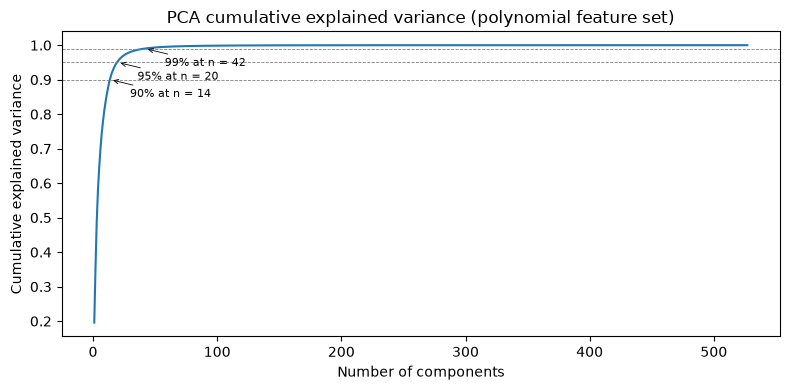

In [4]:
pca_full = fl.plot_pca_variance(
    poly_df,
    title='PCA cumulative explained variance (polynomial feature set)',
)

## 5. Component count scan

Explained variance measures information about the features, not about the target, so the component count is chosen by cross-validated R² instead. The grid is log-spaced because the interesting transitions happen at small counts.

n =    1: mean R2 = 0.4745 ± 0.1208
n =    2: mean R2 = 0.4738 ± 0.1208
n =    5: mean R2 = 0.4890 ± 0.1377


n =   10: mean R2 = 0.5349 ± 0.1748


n =   20: mean R2 = 0.6316 ± 0.1047


n =   40: mean R2 = 0.6572 ± 0.0879


n =   80: mean R2 = 0.7026 ± 0.0577


n =  160: mean R2 = 0.7104 ± 0.0490


n =  320: mean R2 = 0.6689 ± 0.1029


n =  527: mean R2 = 0.0894 ± 1.0367


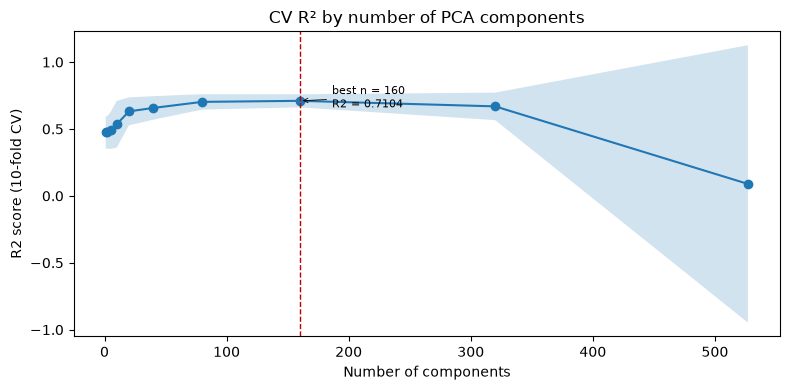

Selected 160 components.


In [5]:
max_n = poly_df.shape[1]
component_grid = sorted({n for n in (1, 2, 5, 10, 20, 40, 80, 160, 320, 640, max_n) if n <= max_n})

scan_df = fl.scan_pca_components(poly_df, housing_df['MedHouseVal'], component_grid)

best_n = fl.plot_pca_component_scan(
    scan_df,
    title='CV R² by number of PCA components',
 )
print(f'Selected {best_n} components.')

## 6. Build final component frame

The final dataset holds the selected principal components plus the target. Interpretability of individual columns is traded away for orthogonality and the CV-optimal dimensionality.

In [6]:
x_scaled = StandardScaler().fit_transform(poly_df)
components = PCA(n_components=best_n).fit_transform(x_scaled)

final_df = pd.DataFrame(
    components,
    columns=[f'PC{i + 1}' for i in range(best_n)],
    index=housing_df.index,
)

final_df['MedHouseVal'] = housing_df['MedHouseVal']

print(f'Final frame: {final_df.shape[0]} rows x {final_df.shape[1]} columns')

Final frame: 20640 rows x 161 columns


## 7. Performance evaluation

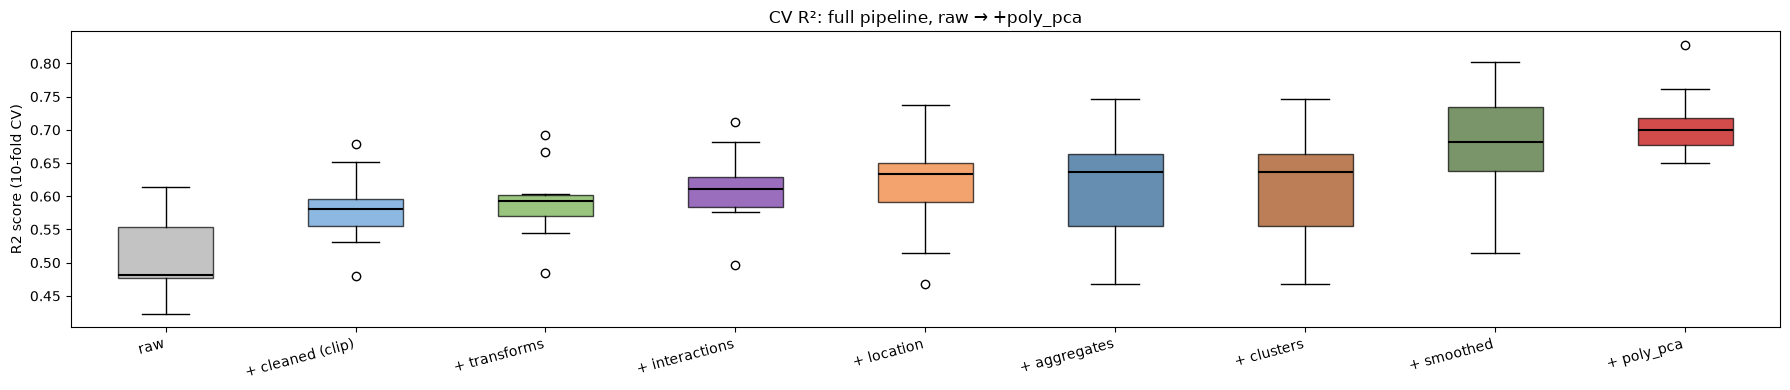

                      raw: mean R2 = 0.5110 ± 0.0593  (+0.00% vs raw)
         + cleaned (clip): mean R2 = 0.5811 ± 0.0536  (+13.71% vs raw)
             + transforms: mean R2 = 0.5923 ± 0.0551  (+15.90% vs raw)
           + interactions: mean R2 = 0.6122 ± 0.0561  (+19.81% vs raw)
               + location: mean R2 = 0.6201 ± 0.0786  (+21.34% vs raw)
             + aggregates: mean R2 = 0.6199 ± 0.0851  (+21.31% vs raw)
               + clusters: mean R2 = 0.6199 ± 0.0851  (+21.31% vs raw)
               + smoothed: mean R2 = 0.6810 ± 0.0777  (+33.26% vs raw)
               + poly_pca: mean R2 = 0.7104 ± 0.0490  (+39.02% vs raw)


In [7]:
results_df = fl.add_pipeline_step(
    None,
    '+ poly_pca',
    final_df.drop('MedHouseVal', axis=1),
    final_df['MedHouseVal'],
    color=PIPELINE_COLORS.get('+ poly_pca', '#c00000'),
    results_path=PIPELINE_RESULTS_PATH,
 )

fl.plot_pipeline_steps(
    results_df,
    title='CV R²: full pipeline, raw → +poly_pca',
    results_path=PIPELINE_RESULTS_PATH,
 )

### Evaluation caveats

An audit of the finished pipeline quantified the main sources of optimism in the numbers above:

- Fold design: the pipeline uses sequential unshuffled 10-fold CV. Dataset rows are ordered geographically, so folds partially separate regions, which makes the headline numbers conservative rather than inflated; shuffled folds score about 0.81 for this stage versus 0.71 here. Under strict spatial holdout (GroupKFold over 32 geohash cells) the final stage scores about 0.63, and every stage improvement survives that stricter test, so the progressive gains are real signal rather than fold-adjacency effects.
- Full-data PCA: fitting the scaler and PCA on all rows before cross-validation adds about +0.006 R2 compared with fitting them inside each training fold. PCA never sees the target, so this inflation is small and bounded.
- p_censored interactions: the 32 polynomial terms involving p_censored contribute about +0.016 R2 under strict per-fold PCA. The feature is built out-of-fold, so this is legitimate signal, but it models the target's top-coding at 5.0, which is a data-collection artifact rather than a housing fundamental.

## 8. Save output

In [8]:
out_path = DATA_DIR / 'final.csv'
final_df.to_csv(out_path, index=False)
print(f'Saved: {out_path}')

Saved: /workspaces/featurely/data/fsa-feature-engineering-challenge/final.csv
